# 🦋 **Bootcamp Data Analytics 2026 - Challenge Testes de Hipótese**


<img src='https://github.com/squad-ada-lovelace/Desafio_04-Teste_de_Hipotese/blob/main/assets/1.png?raw=true'>

## **Squad Ada Lovelace** 💜
<img src='https://github.com/squad-ada-lovelace/.github/blob/9c0642b697aac34bf6e9c323ff92d95d19a23b78/assets/squad_header.png?raw=true'>

## **Organização**

<img src='https://github.com/squad-ada-lovelace/Desafio_04-Teste_de_Hipotese/blob/main/assets/3.png?raw=true'>

## **Contexto**
<img src='https://github.com/squad-ada-lovelace/Desafio_04-Teste_de_Hipotese/blob/main/assets/4.png?raw=true'>



---



## **Imports**

In [ ]:
# Análise de dados
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Testes estatísticos
from scipy import stats
from scipy.stats import f_oneway, pearsonr, shapiro, kruskal
from statsmodels.stats.weightstats import ztest
import statsmodels.api as sm

# Dataframe
df_original = pd.read_csv("https://raw.githubusercontent.com/squad-ada-lovelace/Desafio_04-Teste_de_Hipotese/refs/heads/main/suplementos.csv")
df = df_original.copy()

In [ ]:
# Definição do tema geral
paleta_cores = ["#C3D350", "#753192", "#575D90", "#D5D38F", "#941C2F"]
sns.set_theme(
    style="whitegrid",
    palette=paleta_cores,
    font="sans-serif",
    rc={"axes.titlesize": 12, "axes.labelsize": 10}
)



---



## **Análise Exploratória de Dados**

O dataframe não tem duplicatas nem nulos e **não precisa de tratamento inicial**.

É composto de **5 colunas** e **300 registros**.

Variáveis do tipo **str**, **int** e **float**.

### Dicionário de dados:

**id_produto *(str)***: Código identificador do suplemento (Fórmula 1, 2 ou 3).  <br/>
**id_atleta *(int)***: Código identificador do atleta que participou do estudo.<br/>
**ganho_massa *(float)***: Quantidade de massa muscular ganha (em kg) após 8 semanas de uso. <br/>
**idade *(int)***: Idade do atleta.<br/>
**frequencia_treino *(int)***: Número médio de treinos semanais do atleta.


In [ ]:
# Inspecionando as primeiras 5 linhas
df.head()

,id_produto,id_atleta,ganho_massa,idade,frequencia_treino
0,Fórmula 3,1,2.24,27,5
1,Fórmula 1,2,4.97,35,4
2,Fórmula 3,3,0.88,30,6
3,Fórmula 3,4,0.09,22,6
4,Fórmula 1,5,2.47,18,6


In [ ]:
# Resumo do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_produto         300 non-null    object 
 1   id_atleta          300 non-null    int64  
 2   ganho_massa        300 non-null    float64
 3   idade              300 non-null    int64  
 4   frequencia_treino  300 non-null    int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 11.8+ KB


In [ ]:
# Resumo - estatística descritiva
df.describe()

,id_atleta,ganho_massa,idade,frequencia_treino
count,300.000000,300.000000,300.000000,300.000000
mean,150.500000,2.466733,28.123333,3.993333
std,86.746758,1.436384,6.493742,1.430657
min,1.000000,0.030000,18.000000,2.000000
25%,75.750000,1.267500,22.000000,3.000000
50%,150.500000,2.400000,28.000000,4.000000
75%,225.250000,3.612500,34.000000,5.000000
max,300.000000,4.980000,39.000000,6.000000


In [ ]:
# Checagem de duplicatas
df.duplicated().sum()

np.int64(0)

In [ ]:
# Checagem de nulos
df.isnull().sum()

,0
id_produto,0
id_atleta,0
ganho_massa,0
idade,0
frequencia_treino,0


## **1. Faça uma análise exploratória dos dados:**

### **Qual é a média e a mediana do ganho de massa para cada suplemento?**
  * Fórmula 1: média = 2.66 | mediana = 2.67
  * Fórmula 2: média = 2.35 | mediana = 2.15
  * Fórmula 3: média = 2.39 | mediana = 2.35

In [ ]:
df_sumario = df.groupby("id_produto")["ganho_massa"].agg(["mean", "median", "sum", "count", ("%", lambda x: x.sum() / df["ganho_massa"].sum()*100)]).round(2)
df_sumario

,mean,median,sum,count,%
id_produto,,,,,
Fórmula 1,2.66,2.67,263.00,99,35.54
Fórmula 2,2.35,2.15,220.91,94,29.85
Fórmula 3,2.39,2.35,256.11,107,34.61


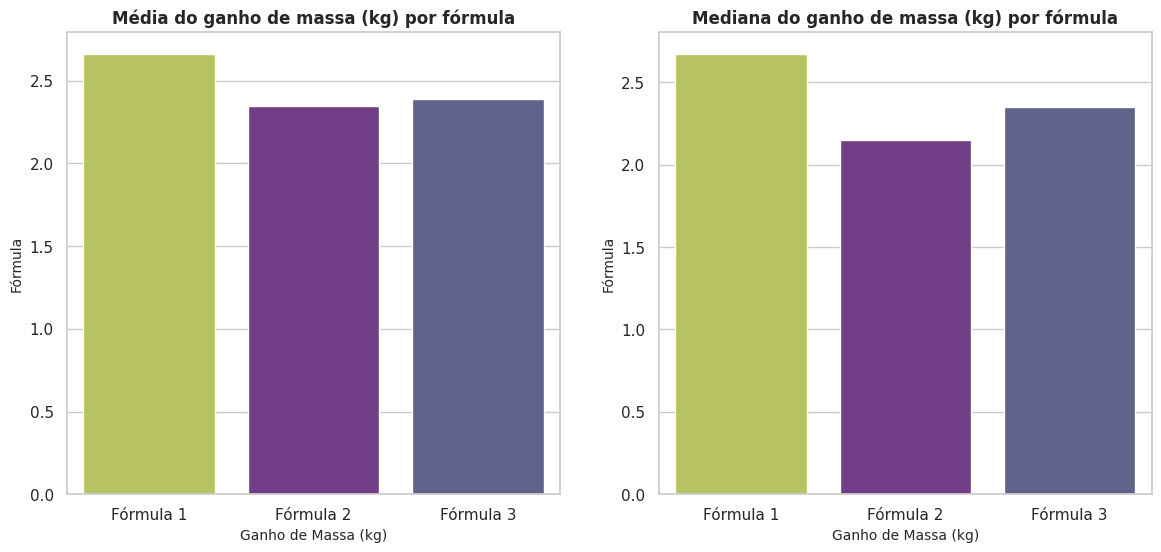

In [ ]:
# Plotando a média e a mediana em gráficos de barra para comparação

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=df_sumario,
    x="id_produto",
    y="mean",
    hue="id_produto",
    ax=axes[0]
)

sns.barplot(
    data=df_sumario,
    x="id_produto",
    y="median",
    hue="id_produto",
    ax=axes[1]
)



axes[0].set_title('Média do ganho de massa (kg) por fórmula', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ganho de Massa (kg)')
axes[0].set_ylabel('Fórmula')

axes[1].set_title('Mediana do ganho de massa (kg) por fórmula', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ganho de Massa (kg)')
axes[1].set_ylabel('Fórmula')
plt.show()

##

### **Como os dados estão distribuídos? Utilize histogramas e boxplots para visualizar as diferenças entre as fórmulas.**
    * Os histogramas indicam uma distribuição multimodal
    * Fórmula 1: pico de frequência em 1.25 e 4.75
    * Fórmula 2: pico de frequência em 1.75 e 1.25
    * Fórmula 3: pico de frequência em 0.25 e 1.75


In [ ]:
# Separando os diferentes valores de ganho de massa de acordo com a fórmula
formula1 = df[df['id_produto'] == 'Fórmula 1'].copy()
formula2 = df[df['id_produto'] == 'Fórmula 2'].copy()
formula3 = df[df['id_produto'] == 'Fórmula 3'].copy()

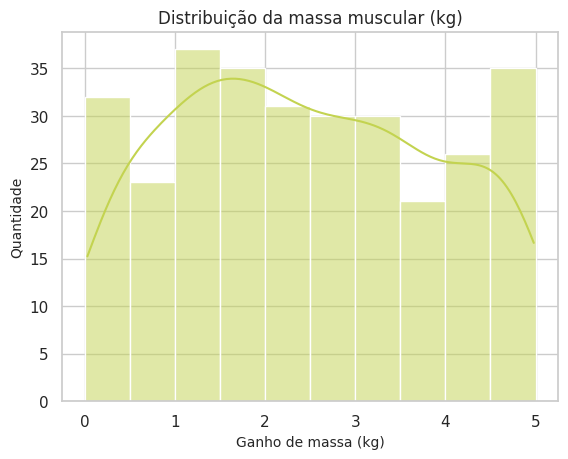

In [ ]:
#Ganho de massa (histograma) - Total, não está separado por fórmula
df_ganho_massa = df['ganho_massa'].copy()
ganho_maximo = df['ganho_massa'].max()
bins = np.arange(0, ganho_maximo + 0.5, 0.5)

sns.histplot(df_ganho_massa, bins = bins, kde= True)
plt.title('Distribuição da massa muscular (kg)')
plt.xlabel('Ganho de massa (kg)')
plt.ylabel('Quantidade')
plt.show()

In [ ]:

fig = make_subplots(rows=1, cols=3, subplot_titles=("Fórmula 1", "Fórmula 2", "Fórmula 3"))

# Fórmula 1
fig.add_trace(go.Histogram(x=formula1["ganho_massa"], nbinsx=10, texttemplate="%{x}", marker=dict(color= "#C3D350", line=dict(color="white", width=1.0))),
    row=1, col=1)

# Fórmula 2
fig.add_trace(go.Histogram(x=formula2["ganho_massa"], nbinsx=10, texttemplate="%{x}", marker=dict(color= "#753192", line=dict(color="white", width=1.0))),
    row=1, col=2)

# Fórmula 3
fig.add_trace(go.Histogram(x=formula3["ganho_massa"], nbinsx=10, texttemplate="%{x}", marker=dict(color="#575D90", line=dict(color="white", width=1.0))),
    row=1, col=3)

fig.update_layout(title_text="Histograma - Fórmula de produto X ganho de massa (kg)", title_x=0.5, showlegend=False)
fig.show()

 * Os boxplots indicam que as amplitudes dos valores para as 3 fórmulas são muito parecidas
    * Fórmula 1: a maior concentração dos dados fica entre 1.4 e 3.7
    * Fórmula 2: a maior concentração dos dados fica entre 1.3 e 3.4, indica uma tendência a resultados menores
    * Fórmula 3: a maior concentração dos dados fica entre 1.1 e 3.7, é a fórmula com maior variação de valores

In [ ]:
# gerando o boxplot da ganho de massa em função da fórmula
fig = make_subplots(rows=1, cols=3, subplot_titles=("Fórmula 1", "Fórmula 2", "Fórmula 3"))

# Fórmula 1
fig.add_trace(go.Box(y=formula1["ganho_massa"], marker_color="#C3D350", boxpoints="outliers"),
    row=1, col=1)

# Fórmula 2
fig.add_trace(go.Box(y=formula2["ganho_massa"], marker_color="#753192", boxpoints="outliers"),
    row=1, col=2)

# Fórmula 3
fig.add_trace(go.Box(y=formula3["ganho_massa"], marker_color="#575D90", boxpoints="outliers"),
    row=1, col=3)

fig.update_layout(title_text="Box plot - Fórmula de Produto X Ganho de Massa", title_x=0.5, showlegend=False)

fig.show()

### Há outliers no ganho de massa muscular? O que isso pode indicar?


  * Não há outliers no ganho de massa muscular. Isso indica que a distribuição dos valores é uniforme, ou seja, não há influência de valores extremos em nenhuma das 3 fórmulas.

In [ ]:
# Verificação de outliers
z_score = stats.zscore(df["ganho_massa"])
df_outliers = df[(z_score > 3) | (z_score < -3)].copy()

if df_outliers.shape[0] == 0:
  print("Não há outliers na coluna 'ganho_massa'")
else:
  print(f"Há {df_outliers.shape[0]} outliers na coluna 'ganho_massa'")


Não há outliers na coluna 'ganho_massa'


## **2. Há diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas?**


Não há diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas.

#### Processo de resolução:


##### Definindo H0 e H1:

**H0: Não há diferença estatisticamente significativa no ganho de massa muscular médio entre as três fórmulas  
H1: Há diferença estatisticamente significativa no ganho de massa muscular médio entre as três fórmulas**

Como buscamos identificar uma diferença nas médias, concluímos que o teste é bilateral.

##### Escolhendo o teste estatístico

A presença de três grupos nos leva a consideração da ANOVA para o teste de significância estatística, no entanto precisamos verificar os critérios de distribuição dos dados:

* preciso que os dados sigam a distribuição normal,
* suas variâncias sejam próximas

Verifica-se nos dados abaixo que a normalidade não é atendida, embora a variância sim.



<Axes: ylabel='Frequency'>

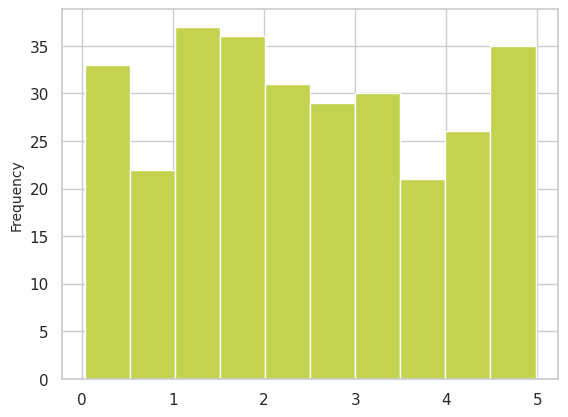

In [ ]:
# Visualização rápida da distribuição de ganho de massa > não segue a normal
df['ganho_massa'].plot(kind='hist')

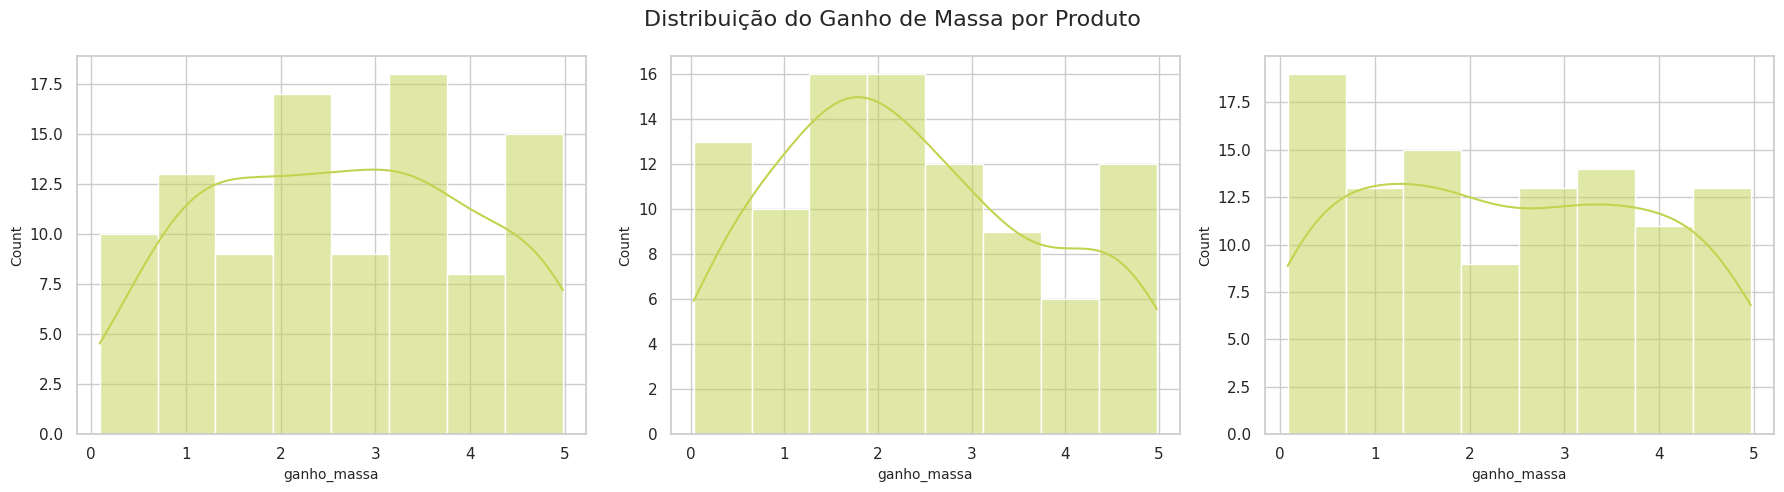

In [ ]:
# Verificando histograma por produto:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição do Ganho de Massa por Produto', fontsize=16)

# Gráfico 1 (axe[0])
sns.histplot(formula1['ganho_massa'], kde = True, ax = axes[0])

# Gráfico 2 (axe[1])
sns.histplot(formula2['ganho_massa'], kde = True, ax = axes[1])

# Gráfico 3 (axe[2])
sns.histplot(formula3['ganho_massa'], kde = True, ax = axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# Teste de normalidade

for i in range(1, 4):
  estatistica, p_value = stats.shapiro(eval(f"formula{i}")["ganho_massa"])
  if p_value > 0.05:
    print(f"Fórmula {i} - Distribuição normal")
  else:
    print(f"Fórmula {i} - Distribuição não é normal")

Fórmula 1 - Distribuição não é normal
Fórmula 2 - Distribuição não é normal
Fórmula 3 - Distribuição não é normal


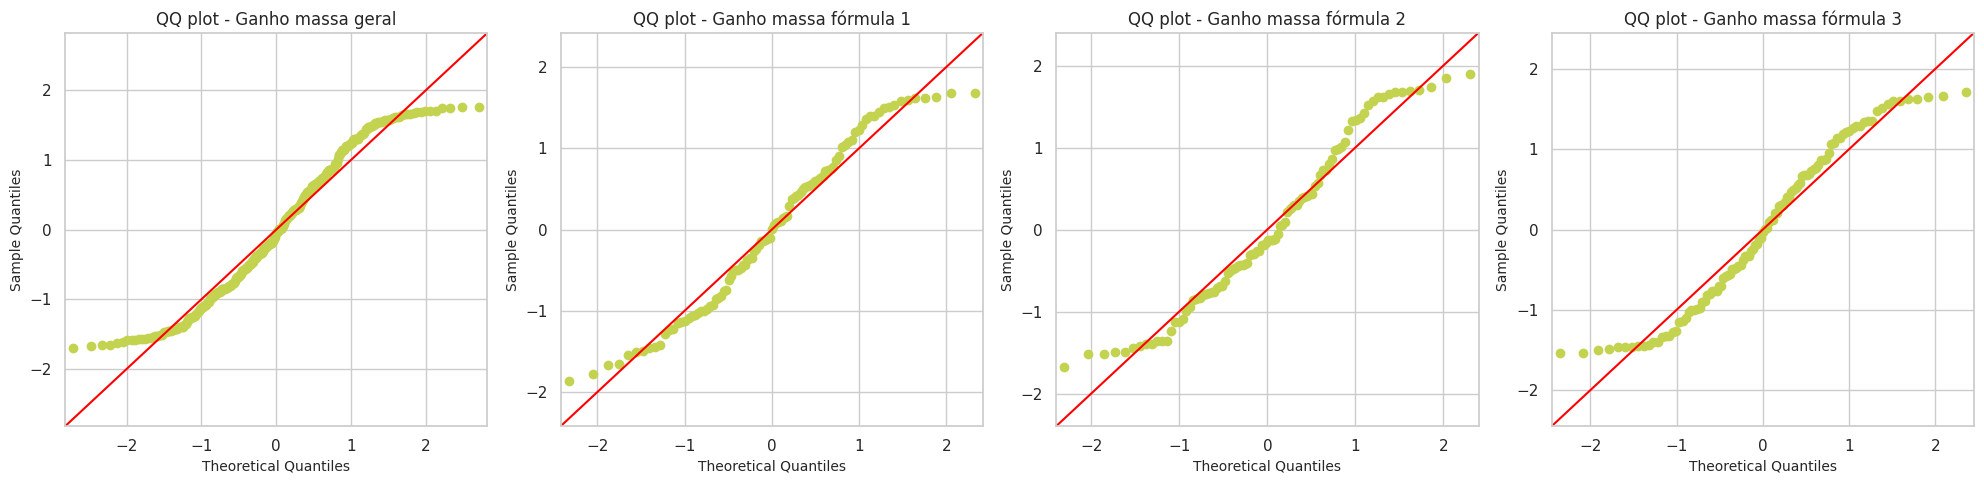

In [ ]:
# QQ Plot para visualizar a não-normalidade da distribuição
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sm.qqplot(df["ganho_massa"], line="45", fit=True, ax=axes[0])
axes[0].set_title("QQ plot - Ganho massa geral")

sm.qqplot(formula1["ganho_massa"], line="45", fit=True, ax=axes[1])
axes[1].set_title("QQ plot - Ganho massa fórmula 1")

sm.qqplot(formula2["ganho_massa"], line="45", fit=True, ax=axes[2])
axes[2].set_title("QQ plot - Ganho massa fórmula 2")

sm.qqplot(formula3["ganho_massa"], line="45", fit=True, ax=axes[3])
axes[3].set_title("QQ plot - Ganho massa fórmula 3")

plt.tight_layout()
plt.show()

In [ ]:
# Teste de Levene para verificar homocedasticidade (usada a mediana pois a distribuição é assimétrica):

estatistica, pvalor = stats.levene(formula1['ganho_massa'], formula2['ganho_massa'], formula3['ganho_massa'], center = "median")

print(f"Estatística de Levene: {estatistica:.4f}")
print(f"p-valor: {pvalor:.4f}")

alpha = 0.05

if pvalor < alpha:
    print("Pelo menos uma das variâncias é significativamente diferente.")
else:
    print("Não há evidências de diferença entre as variâncias (variâncias homogêneas).")


Estatística de Levene: 1.2911
p-valor: 0.2765
Não há evidências de diferença entre as variâncias (variâncias homogêneas).


#### **Teste de hipótese - ANOVA**

**Escolha do teste:**
1. Apesar dos dados não gerarem uma distribuição normal, ainda é possível utilizar ANOVA por conta do tamanho da amostra (todas > 30): O teorema do limite central informa que para amostras grandes, a distribuição da média amostral se aproxima de uma distribuição normal, mesmo que os dados originais não sejam normais.
2. Nenhuma das curvas apresenta assimetria extrema (como uma cauda gigantesca para um dos lados) ou picos isolados afastados do restante dos dados (outliers graves), e os três grupos possuem contagens muito próximas e comparáveis (99, 94 e 107).

In [ ]:
estatistica, pvalor = stats.f_oneway(formula1['ganho_massa'], formula2['ganho_massa'], formula3['ganho_massa'])

print(f"Estatística da ANOVA: {estatistica:.4f}")
print(f"p-valor: {pvalor:.4f}")

#Nível de significância:
alpha = 0.05

if pvalor < alpha:
    print(f"Conclusão (p-valor < {alpha}): Rejeitamos H0.")
    print("Há diferença estatisticamente significativa no ganho de massa muscular entre pelo menos uma das três fórmulas.")
else:
    print(f"Conclusão (p-valor >= {alpha}): Não rejeitamos H0.")
    print("Não há diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas. O desempenho delas é equivalente.")

Estatística da ANOVA: 1.3161
p-valor: 0.2697
Conclusão (p-valor >= 0.05): Não rejeitamos H0.
Não há diferença estatisticamente significativa no ganho de massa muscular entre as três fórmulas. O desempenho delas é equivalente.




---



## **3. Existe correlação entre idade e ganho de massa muscular? Atletas mais jovens ou mais velhos têm resultados diferentes?**

Os pontos estão espalhados no gráfico de forma aleatória, e não há uma relação linear clara entre as variáveis de idade e ganho de massa muscular, portanto, não parece existir correlação entre elas.

Mas, para ter certeza, rodamos testes estatísticos no dataset.

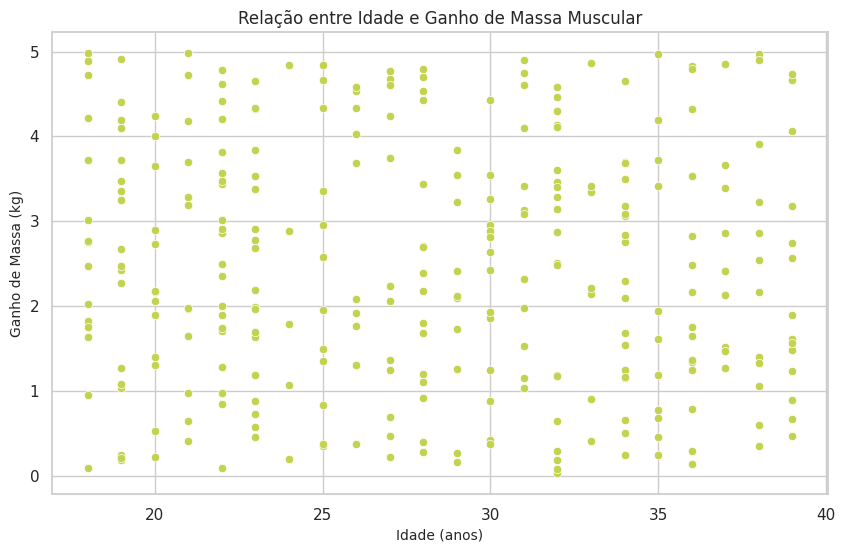

In [ ]:
# Gráfico de dispersão entre Idade e Ganho de Massa
plt.figure(figsize=(10, 6))
sns.scatterplot(df, x='idade', y='ganho_massa')
plt.title('Relação entre Idade e Ganho de Massa Muscular')
plt.xlabel('Idade (anos)')
plt.ylabel('Ganho de Massa (kg)')
plt.show()

#### Correlação - Spearman

**Escolha do teste de correlação:**
* Dados não apresentam distribuição normal ➝ QQ plot e teste de Shapiro-Wilk (amostras pequenas a médias, com até algumas centenas de observações)

In [ ]:
parametros = ["idade", "ganho_massa"]

for p in parametros:
  stat, p_value = stats.shapiro(df[p])
  if p_value > 0.05:
    print(f"{p} - Distribuição normal")
  else:
    print(f"{p} - Distribuição não é normal")

idade - Distribuição não é normal
ganho_massa - Distribuição não é normal


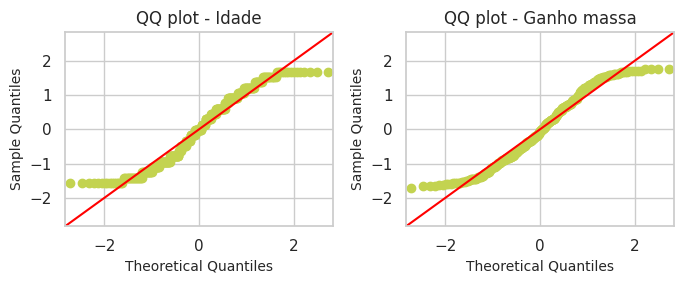

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

sm.qqplot(df["idade"], line="45", fit=True, ax=axes[0])
axes[0].set_title("QQ plot - Idade")

sm.qqplot(df["ganho_massa"], line="45", fit=True, ax=axes[1])
axes[1].set_title("QQ plot - Ganho massa")

plt.tight_layout()
plt.show()

In [ ]:
stat_corr, p_corr = stats.spearmanr(df["idade"], df["ganho_massa"])

if p_corr > 0.05:
  print("Não há correlação entre idade e ganho de massa")
else:
  print("Há correlação entre idade e ganho de massa")

Não há correlação entre idade e ganho de massa


In [ ]:
# Binning

"""
Jovem adulto: <30
Adulto:  30 a 60
Idoso: > 60
"""

intervalo = [0, 30, 60, 120]
grupos = ["Jovem adulto", "Adulto", "Idoso"]

df["grupo_idade"] = pd.cut(df["idade"], bins=intervalo, labels=grupos, right=False)

print(f"""Distribuição grupos idade:
- Jovem adulto: {df[df["grupo_idade"] == "Jovem adulto"].shape[0]}
- Adulto: {df[df["grupo_idade"] == "Adulto"].shape[0]}
- Idoso: {df[df["grupo_idade"] == "Idoso"].shape[0]}""")

Distribuição grupos idade:
- Jovem adulto: 166
- Adulto: 134
- Idoso: 0


In [ ]:
# Teste de Spearman para jovens adultos
estatistica_corr, p_corr = stats.spearmanr(df[df["grupo_idade"] == "Jovem adulto"]["idade"], df[df["grupo_idade"] == "Jovem adulto"]["ganho_massa"])

if p_corr > 0.05:
  print("Jovens adultos - Não há correlação entre idade e ganho de massa")
else:
  print("Jovens adultos - Há correlação entre idade e ganho de massa")

Jovens adultos - Não há correlação entre idade e ganho de massa


In [ ]:
# Teste de Spearman para adultos
estatistica_corr, p_corr = stats.spearmanr(df[df["grupo_idade"] == "Adulto"]["idade"], df[df["grupo_idade"] == "Adulto"]["ganho_massa"])

if p_corr > 0.05:
  print("Adultos - Não há correlação entre idade e ganho de massa")
else:
  print("Adultos - Há correlação entre idade e ganho de massa")

Adultos - Não há correlação entre idade e ganho de massa


#### Teste de hipótese - Mann-Whitney

**Escolha do teste:**
1. Dados não apresentam distribuição normal ➝ QQ plot e teste de Shapiro-Wilk (amostras pequenas a médias, com até algumas centenas de observações)
2. Amostras não são pareadas (dados são independentes)
3. Comparação entre 2 grupos

**Hipóteses:**
* H0: **não há correlação** entre idade e ganho de massa muscular entre jovens adultos e adultos
* Ha: **há correlação** entre idade e ganho de massa muscular entre jovens adultos e adultos

In [ ]:
estatistica_mw, p_mw = stats.mannwhitneyu(df[df["grupo_idade"] == "Jovem adulto"]["ganho_massa"], df[df["grupo_idade"] == "Adulto"]["ganho_massa"])

if p_mw < 0.05:
  print("Rejeitamos H0 - Há correlação entre idade e ganho de massa muscular entre jovens adultos e adultos")
else:
  print("Não rejeitamos H0 - Não há correlação entre idade e ganho de massa muscular entre jovens adultos e adultos")

Não rejeitamos H0 - Não há correlação entre idade e ganho de massa muscular entre jovens adultos e adultos




---



## **4. Atletas que treinam mais frequentemente ganham mais massa muscular independentemente do suplemento?**

Como a correlação ficou próxima de zero, não é possível afirmar que atletas mais jovens ou mais velhos tem ganhos de massa diferentes.

Utilizamos o método Spearman por consideramos que não há normalidade nos dados.

<Axes: >

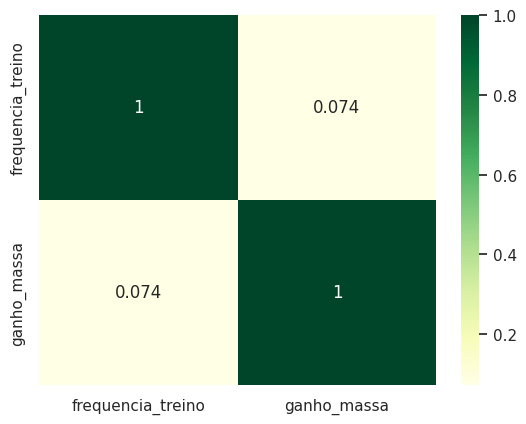

In [ ]:
# Plotagem no dataframe inteiro
df_corr_massa = df[['frequencia_treino', 'ganho_massa']].corr(method='spearman')
sns.heatmap(df_corr_massa, cmap="YlGn", annot=True)

---

## **5. Existe alguma correlação entre idade, frequência de treino e a eficácia do suplemento?**

Considerando os testes já rodados, não foi possível encontrar correlações significativas entre as variáveis. Relembrando:

* Fórmulas (ANOVA): Não geraram diferença significativa no ganho de massa (p-valor: 0.2697).
* Idade (Correlação de Spearman): Não apresentou relação com o ganho de massa (correlação: 0.074).
* Frequência de Treino (Mannwhitney): Também não apresentou diferença significativa no ganho de massa (p-valor: 0.42).

Portanto, não foram encontradas evidências estatisticamente significativas de que o tipo de fórmula de suplemento, a idade do atleta ou a frequência semanal de treinos influenciem o ganho de massa muscular na população analisada (todos os p-valores > 0.05).

<Axes: >

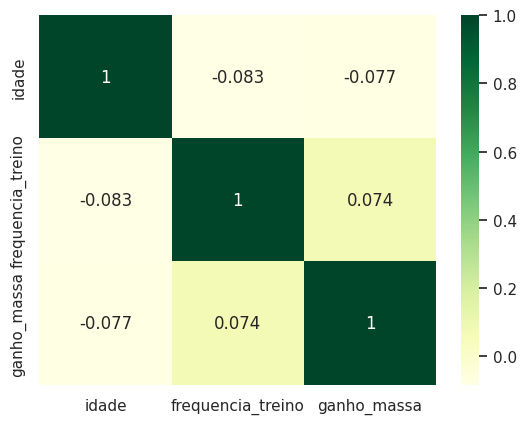

In [ ]:
df_corr = df[['idade', 'frequencia_treino', 'ganho_massa']].corr(method='spearman')
sns.heatmap(df_corr, cmap="YlGn", annot=True)



---



## **6. Qual fórmula você recomendaria para atletas que treinam mais de 5 vezes por semana? Justifique sua escolha.**

Mas, há diferenças para quem treina mais de 5 vezes? O teste t é utilizado novamente.

**H0: Atletas que treinam mais de 5 dias tem desempenho igual aos que não treinam. <br/>
H1: Atletas que treinam mais de 5 dias tem desempenho diferente (maior) que os que não treinam.**

In [ ]:
treinam_mais_5 = df[df['frequencia_treino'] > 5]['ganho_massa'].copy()
treinam_menos_5 = df[df['frequencia_treino'] <= 5]['ganho_massa'].copy()

print(f'Quantidade de atletas que treinam mais que 5 dias: {len(treinam_mais_5)}.')
print(f'Quantidade de atletas que treinam 5 dias ou menos: {len(treinam_menos_5)}.')

Quantidade de atletas que treinam mais que 5 dias: 64.
Quantidade de atletas que treinam 5 dias ou menos: 236.


Ainda temos uma amostra grande o suficiente para usar o teste t.

In [ ]:
estatistica, pvalor = stats.ttest_ind(treinam_mais_5, treinam_menos_5)

print(f"p-valor: {pvalor:.4f}")

if pvalor < 0.05:
    print("Treinar mais que 5 dias gera diferença estatisticamente significativa no ganho de massa. \nRejeitamos a hipótese nula.")
else:
    print("Não há diferença estatisticamente significativa entre quem treina mais ou menos de 5 dias.\nNão rejeitamos a hipótese nula.")

p-valor: 0.0224
Treinar mais que 5 dias gera diferença estatisticamente significativa no ganho de massa. 
Rejeitamos a hipótese nula.


Dentre todos os testes rodados, só foi possível encontrar uma diferença significativa de ganho de massa entre quem treina mais de 5 dias e quem não treina, o que indica que a fórmula utilizada não é o fator determinante para o ganho de massa, mas sim a quantidade de dias destinados ao treino. Por isso, os atletas que treinam mais de 5 dias podem optar por qualquer uma das fórmulas, desde que mantenham a sua frequência de treino.

## Facilidades e Desafios
<img src="https://github.com/squad-ada-lovelace/Desafio_04-Teste_de_Hipotese/blob/main/assets/5.png?raw=true">